# Student Performance Analysis

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Cleaning


In [181]:
df=pd.read_csv("student_score.csv")
print(df.head())

   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

In [182]:
df.describe()



,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [184]:
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

In [185]:
#drop unamed column
df=df.drop("Unnamed: 0",axis=1,errors="ignore")
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


In [186]:
#change weekly study hours
df["WklyStudyHours"]=df["WklyStudyHours"].str.replace("05-Oct","5-10")
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


## Gender Distribution


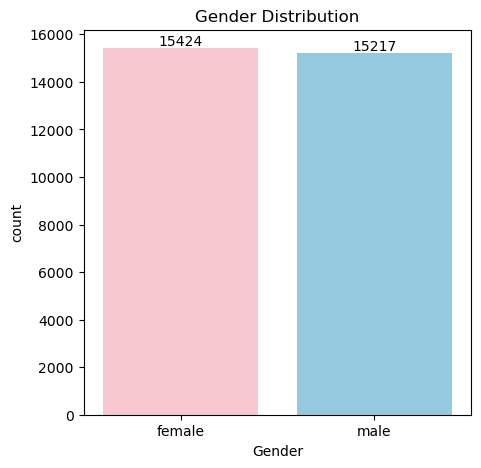

In [187]:
#gender distribution
plt.figure(figsize=(5,5))
plt.title("Gender Distribution")
ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette={"male": "skyblue", "female": "pink"},
    legend=False
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()


In [188]:
# From the above chart, the number of females in the data is slightly higher than the number of males.

## Parent Education and Student Performance


In [189]:
gp0=df.groupby("ParentEduc").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gp0)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


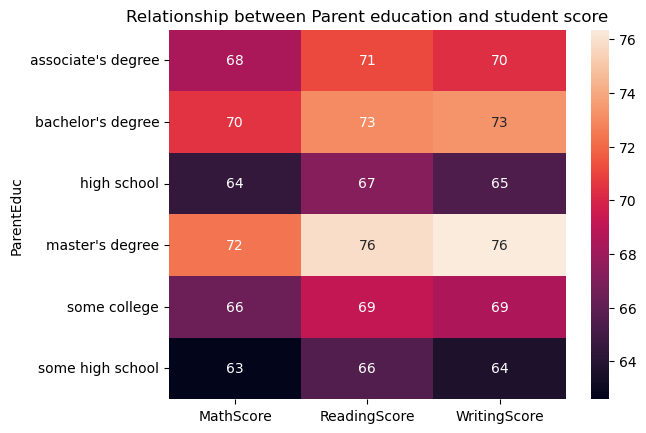

In [190]:
sns.heatmap(gp0,annot=True)
plt.title("Relationship between Parent education and student score")
plt.show()

In [191]:
# From the above chart, we can see that parents' education has an impact on student scores.

#student whose parents have higher education levels usually score better, especially in reading and writing

In [192]:
gp1=df.groupby("ParentMaritalStatus").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gp1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


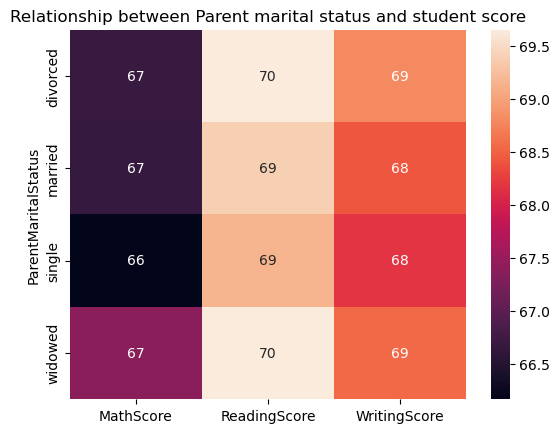

In [193]:
sns.heatmap(gp1,annot=True)
plt.title("Relationship between Parent marital status and student score")
plt.show()

In [194]:
# Parent marital status has little or no impact on student scores.


## Subject-wise Score Distribution

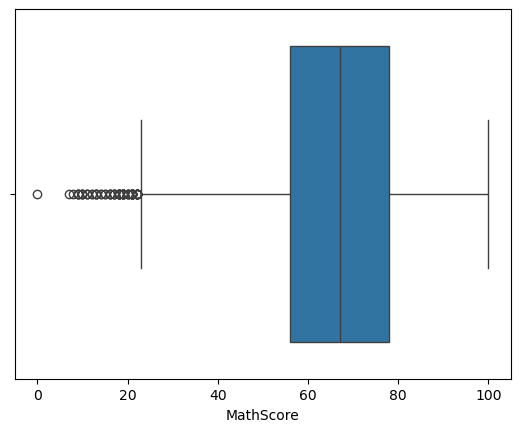

In [195]:
sns.boxplot(data=df,x="MathScore")
plt.show()

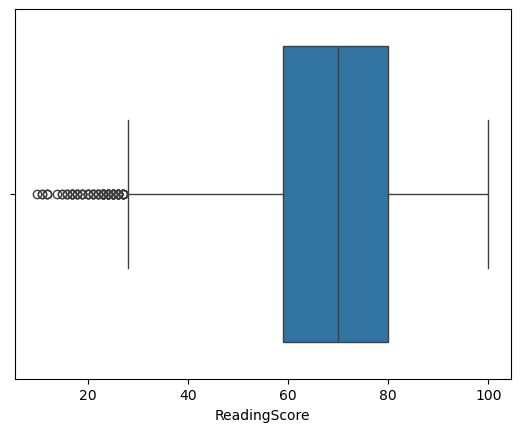

In [196]:
sns.boxplot(data=df,x="ReadingScore")
plt.show()

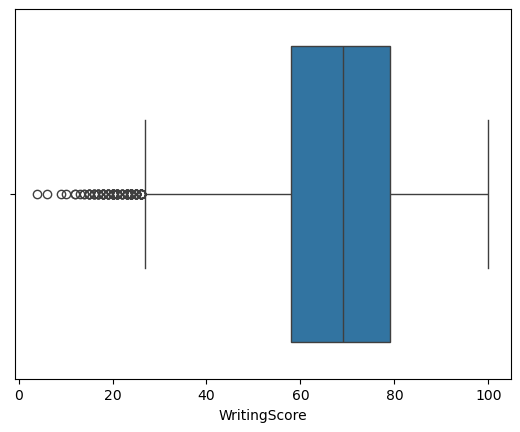

In [197]:
sns.boxplot(data=df,x="WritingScore")
plt.show()

In [198]:
# Math appears to be relatively more difficult than reading and writing.


In [199]:
#total score section
df["TotalScore"] = df["MathScore"] + df["ReadingScore"] + df["WritingScore"]

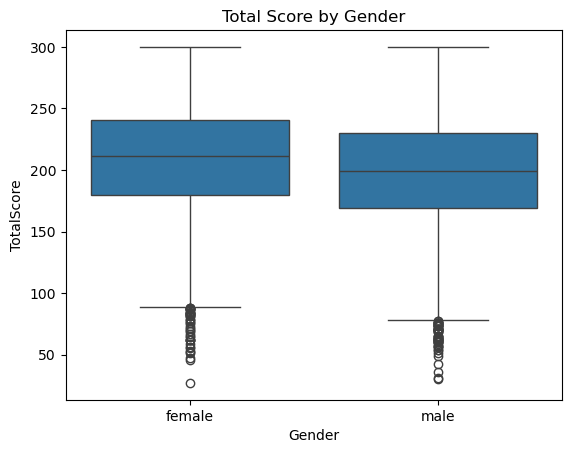

In [200]:
sns.boxplot(data=df, x="Gender", y="TotalScore")
plt.title("Total Score by Gender")
plt.show()

In [201]:
#The total scores of male and female students are quite close, but females have a slightly higher median score.
#This means both genders perform almost equally in academics.

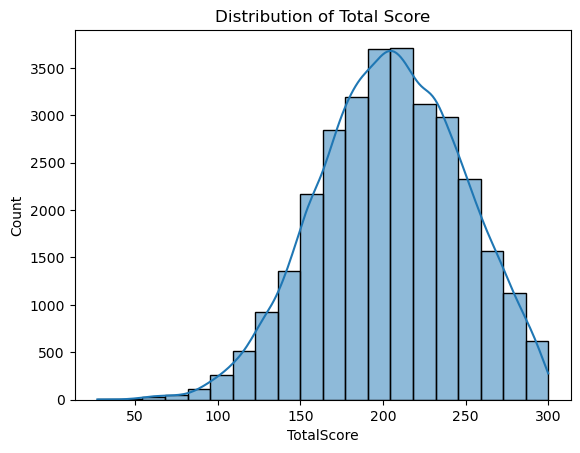

In [202]:
sns.histplot(df["TotalScore"], bins=20, kde=True)
plt.title("Distribution of Total Score")
plt.show()

In [203]:
#Most students score in the middle range, with fewer students scoring extremely high or low.

In [204]:
#Total score gives an overall idea of student performance instead of looking at each subject separately

## Standardized Score (Z-Score)


In [205]:
# Z-score for Total Score
df["ZScore"] = (df["TotalScore"] - df["TotalScore"].mean()) / df["TotalScore"].std()
df[["TotalScore", "ZScore"]].head()

,TotalScore,ZScore
0,216,0.268557
1,247,0.983453
2,271,1.536920
3,143,-1.414906
4,229,0.568352


## Relationship Between Subjects


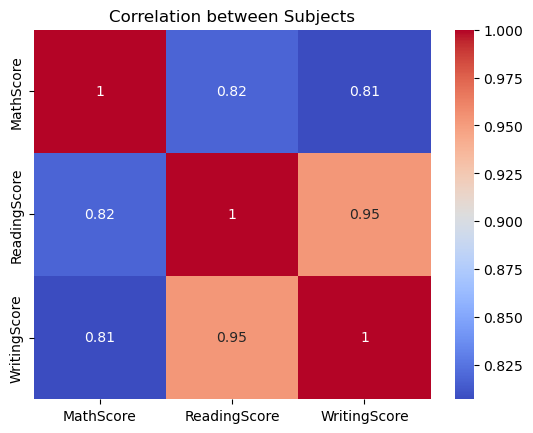

In [206]:
#Correlation Section
corr = df[["MathScore","ReadingScore","WritingScore"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between Subjects")
plt.show()

In [207]:
# Reading and writing scores are closely related, while math is slightly different.


## Effect of Test Preparation


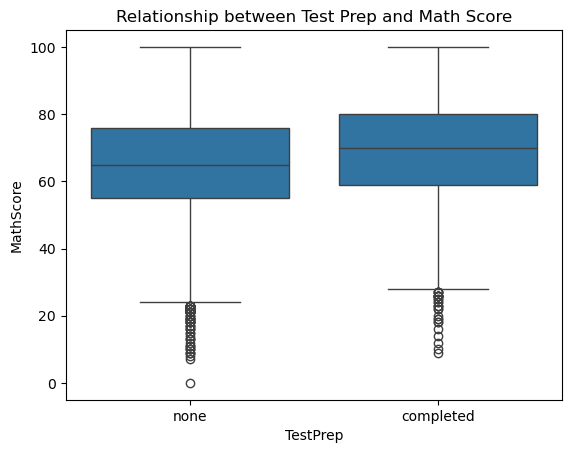

In [208]:
sns.boxplot(data=df,x="TestPrep",y="MathScore")
plt.title("Relationship between Test Prep and Math Score")
plt.show()

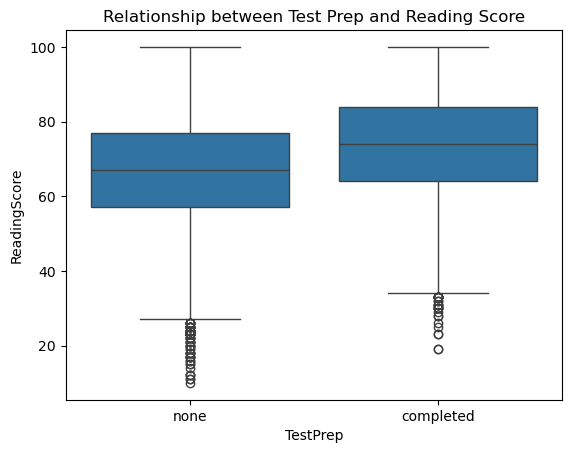

In [209]:
sns.boxplot(data=df,x="TestPrep",y="ReadingScore")
plt.title("Relationship between Test Prep and Reading Score")
plt.show()

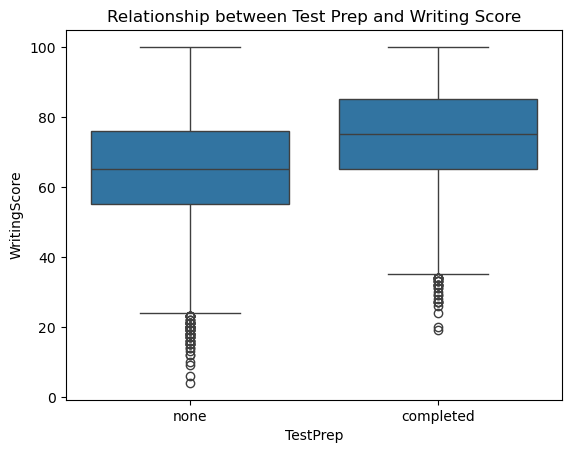

In [210]:
sns.boxplot(data=df,x="TestPrep",y="WritingScore")
plt.title("Relationship between Test Prep and Writing Score")
plt.show()

In [211]:
# Students who completed test preparation generally score higher in all three subjects.


## Sports Activity and Performance


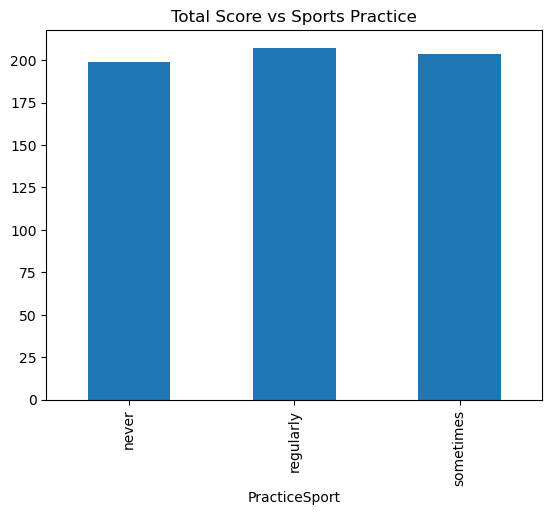

In [212]:
#sports vs performance
gp2 = df.groupby("PracticeSport")["TotalScore"].mean()
gp2.plot(kind="bar")
plt.title("Total Score vs Sports Practice")
plt.show()

In [213]:
#Students who practice sports regularly seem to perform slightly better.

In [214]:
print(df['EthnicGroup'].unique())

[nan 'group C' 'group B' 'group A' 'group D' 'group E']


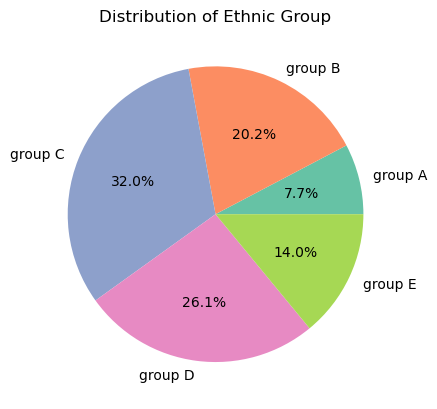

In [221]:
#distribution of ethnic group
groupA = df.loc[(df["EthnicGroup"] =="group A")].count()
groupB = df.loc[(df["EthnicGroup"] =="group B")].count()
groupC = df.loc[(df["EthnicGroup"] =="group C")].count()
groupD = df.loc[(df["EthnicGroup"] =="group D")].count()
groupE = df.loc[(df["EthnicGroup"] =="group E")].count()


l=["group A","group B","group C","group D","group E"]
mlist=[groupA["EthnicGroup"],groupB["EthnicGroup"],groupC["EthnicGroup"],groupD["EthnicGroup"],groupE["EthnicGroup"]]

colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"]
plt.pie(mlist,labels=l,autopct='%1.1f%%',colors=colors)
plt.title("Distribution of Ethnic Group")
plt.show()


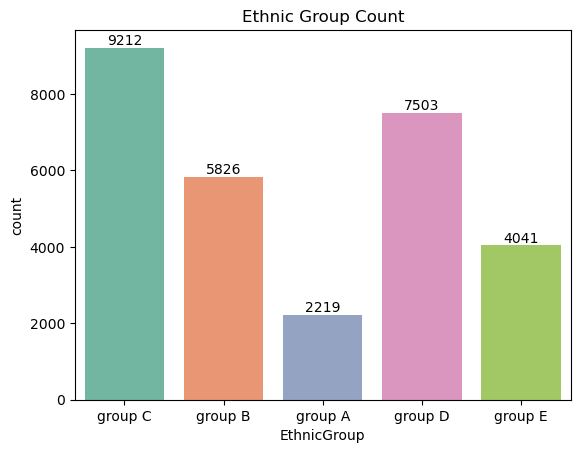

In [216]:
ax=sns.countplot(data=df, x="EthnicGroup",hue="EthnicGroup",palette=colors,legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Ethnic Group Count")
plt.show()

In [217]:
df.sort_values("TotalScore", ascending=False)[
    ["Gender","EthnicGroup","MathScore","ReadingScore","WritingScore","TotalScore"]
].head(5)


,Gender,EthnicGroup,MathScore,ReadingScore,WritingScore,TotalScore
2484,female,group A,100,100,100,300
20396,female,group A,100,100,100,300
2325,male,group E,100,100,100,300
8883,male,group D,100,100,100,300
20498,female,group D,100,100,100,300


In [218]:
df.sort_values("TotalScore")[
    ["Gender","EthnicGroup","MathScore","ReadingScore","WritingScore","TotalScore"]
].head(5)

,Gender,EthnicGroup,MathScore,ReadingScore,WritingScore,TotalScore
55,female,group C,0,17,10,27
14494,male,group D,7,11,12,30
18385,male,group B,10,12,9,31
4719,male,group B,19,11,6,36
30389,male,group B,24,14,4,42


In [219]:
#Top and bottom scoring students to understand the performance range.




## Conclusion


In [220]:
#Overall, this project shows how factors like test preparation, parents’ education, study habits, and activities can influence student performance.